# Imports

In [2]:
from fastai.vision.all import *
from pathlib import Path

## Finetuning

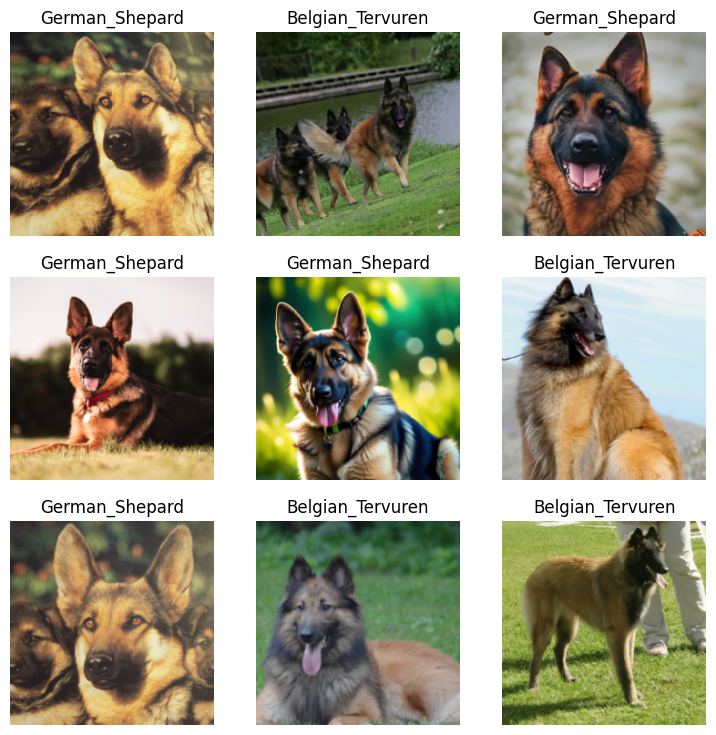

In [1]:
from fastai.vision.all import *
from pathlib import Path

# TODO - change the path!
path = Path(r'C:\Users\modri\Desktop\python\DSPraktikum\dspracticum2025\lesson03\Dataset') / 'train'

dls = ImageDataLoaders.from_folder(
    path,                 # Path to the train folder
    train='.',            # Use the entire train folder for splitting
    valid_pct=0.2,        # 20% of the data will be used for validation
    seed=42,              # Set a seed for reproducibility
    item_tfms=Resize(460),# Resize the images to 460x460 (or your desired size)
    batch_tfms=aug_transforms(size=224, min_scale=0.75), # Data augmentation 
    bs=64                 # Batch size 64
)

dls.show_batch(max_n=9)

In [3]:
import warnings

# to ignore the palette warnings
warnings.filterwarnings(
    "ignore",
    message="Palette images with Transparency expressed in bytes should be converted to RGBA images",
    category=UserWarning
)

In [4]:
learn = vision_learner(dls, resnet18, metrics=error_rate)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\modri/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:13<00:00, 3.51MB/s]


SuggestedLRs(valley=0.0012022644514217973)

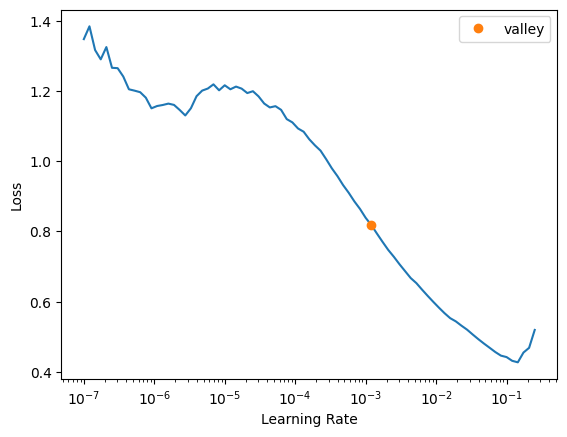

In [5]:
learn.lr_find()

In [6]:
lr = 0.0012022644514217973
epochs = 10

In [7]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(epochs, lr)

epoch,train_loss,valid_loss,error_rate,time
0,0.653879,0.075133,0.016043,02:06


epoch,train_loss,valid_loss,error_rate,time
0,0.117419,0.033853,0.026738,02:48
1,0.074096,0.017208,0.000000,02:33
2,0.054575,0.021740,0.016043,01:49
3,0.047746,0.013980,0.016043,01:29
4,0.036665,0.000807,0.000000,01:29
5,0.029127,0.000284,0.000000,01:51
6,0.022359,0.000226,0.000000,01:45
7,0.017720,0.000217,0.000000,01:30
8,0.015673,0.000181,0.000000,01:27
9,0.016195,0.000172,0.000000,01:24


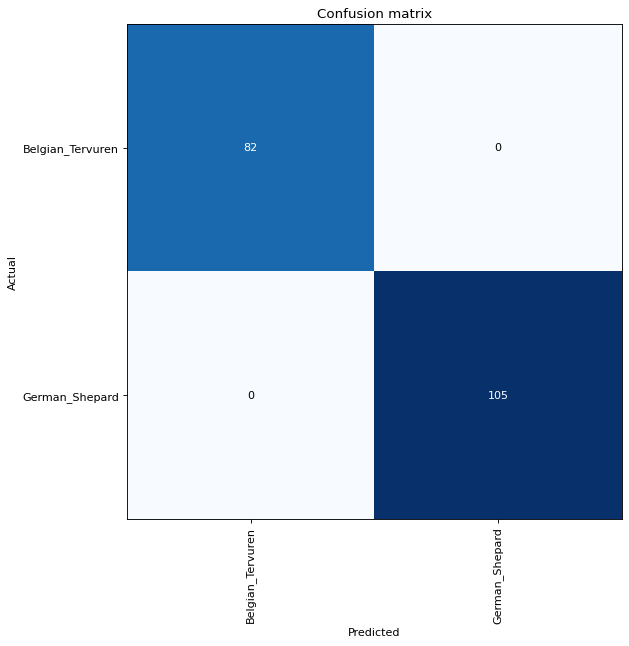

In [8]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(8,8), dpi=80)


### Testing

In [9]:
test_path = Path(r'C:\Users\modri\Desktop\python\DSPraktikum\dspracticum2025\lesson03\Dataset') / 'test'
test_dl = learn.dls.test_dl(get_image_files(test_path))

In [10]:
preds, targets = learn.get_preds(dl=test_dl)
pred_labels = torch.argmax(preds, dim=1)

In [11]:
# Get class names
class_names = learn.dls.vocab
# Convert predictions to class names
pred_class_names = [class_names[i] for i in pred_labels]
true_class_names = [Path(t).parent.name for t in test_dl.items]

In [12]:
from statistics import mean

print("Test error rate:")
print(1 - mean([actual == predicted for actual, predicted in zip(true_class_names, pred_class_names)]))

Test error rate:
0


In [13]:
learn.export('model.pkl')